1. Importar librerías estadísticas y conectar a la BD

In [5]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

sns.set_theme(style="whitegrid")

# Conexión a la BD
load_dotenv('../.env')
engine = create_engine(f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}")

print("Librerías estadísticas cargadas y BD conectada.")


Librerías estadísticas cargadas y BD conectada.


2. Extraer datos para el análisis

Vamos a traer los datos transaccionales y de clientes.

In [6]:
query = """
SELECT 
    v.id_venta,
    v.cantidad,
    p.precio_unitario,
    (v.cantidad * p.precio_unitario) as total_venta,
    cl.region,
    c.categoria
FROM ventas v
JOIN productos p ON v.id_producto = p.id_producto
JOIN clientes cl ON v.id_cliente = cl.id_cliente
JOIN categorias c ON p.id_categoria = c.id_categoria
WHERE v.estado = 'Completa';
"""

df_stats = pd.read_sql(query, engine)
df_stats.head()

,id_venta,cantidad,precio_unitario,total_venta,region,categoria
0,919,5,15.45,77.25,Buenos Aires,Congelados
1,947,1,5.65,5.65,NEA,Lácteos
2,1317,3,15.45,46.35,NEA,Congelados
3,1607,5,3.51,17.55,Centro,Panadería
4,2038,5,5.21,26.05,Buenos Aires,Lácteos


3. Análisis de Distribución y Outliers (Valores Atípicos)

Antes de hacer estadísticas, debemos saber cómo se distribuyen nuestras ventas. ¿Son todas parecidas o hay ventas inusualmente grandes?

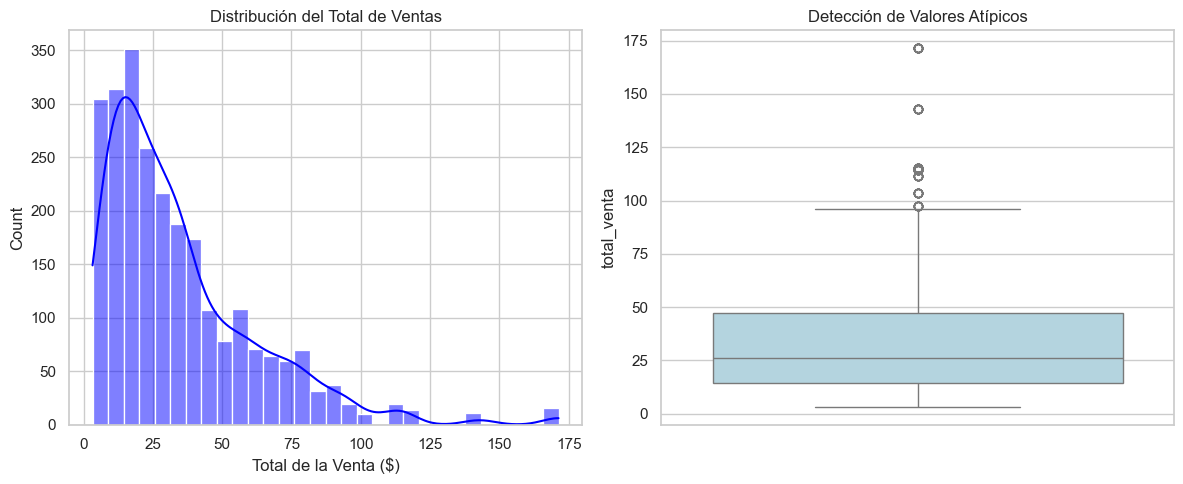

Promedio de venta: $34.77
Mediana de venta: $26.16
Desviación Estándar: $27.90


In [7]:
plt.figure(figsize=(12, 5))

# Histograma para ver la forma de los datos
plt.subplot(1, 2, 1)
sns.histplot(df_stats['total_venta'], bins=30, kde=True, color='blue')
plt.title('Distribución del Total de Ventas')
plt.xlabel('Total de la Venta ($)')

# Boxplot para detectar Outliers (valores atípicos)
plt.subplot(1, 2, 2)
sns.boxplot(y=df_stats['total_venta'], color='lightblue')
plt.title('Detección de Valores Atípicos')

plt.tight_layout()
plt.show()

# Calcular métricas clave
print(f"Promedio de venta: ${df_stats['total_venta'].mean():.2f}")
print(f"Mediana de venta: ${df_stats['total_venta'].median():.2f}")
print(f"Desviación Estándar: ${df_stats['total_venta'].std():.2f}")

Nota de negocio: Si el promedio es mucho más alto que la mediana, significa que hay pocas ventas de un valor altísimo que están distorsionando el promedio.

4. Análisis de Correlación

¿Si un producto es más caro, la gente compra menos cantidad? Vamos a comprobarlo matemáticamente usando la correlación de Pearson.

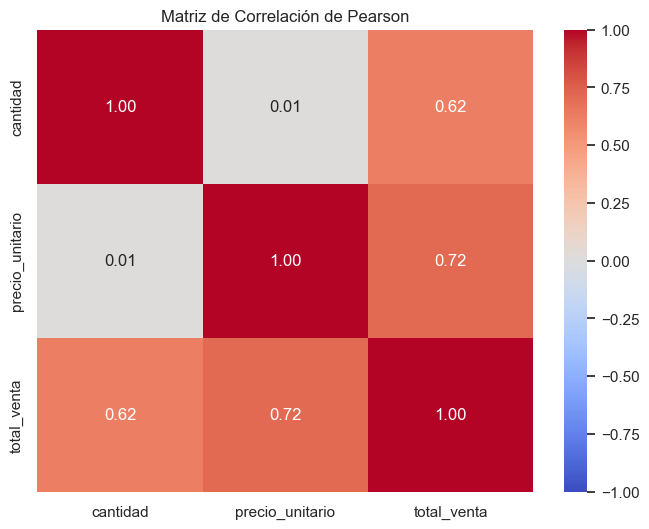

In [8]:
# Seleccionamos solo las variables numéricas
vars_numericas = df_stats[['cantidad', 'precio_unitario', 'total_venta']]

# Calculamos la matriz de correlación
correlacion = vars_numericas.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matriz de Correlación de Pearson')
plt.show()

Interpretación: Un valor cercano a 1 indica que cuando una variable sube, la otra también. Un valor cercano a -1 indica que si una sube, la otra baja. Un valor cercano a 0 indica que no tienen relación.

5. Prueba de Hipótesis (T-Test A/B)

En los registros de error anteriores vimos que tienes clientes en "Patagonia" y "Buenos Aires". Vamos a responder a esta pregunta de negocio con rigor estadístico: ¿Existe una diferencia real en lo que gastan los clientes de la Patagonia vs Buenos Aires, o es simple casualidad?

In [9]:
# Separar las ventas de ambas regiones
ventas_patagonia = df_stats[df_stats['region'] == 'Patagonia']['total_venta']
ventas_bsas = df_stats[df_stats['region'] == 'Buenos Aires']['total_venta']

print(f"Ticket promedio Patagonia: ${ventas_patagonia.mean():.2f}")
print(f"Ticket promedio Buenos Aires: ${ventas_bsas.mean():.2f}\n")

# Realizar T-Test para dos muestras independientes
t_stat, p_value = stats.ttest_ind(ventas_patagonia, ventas_bsas, equal_var=False)

print(f"Estadístico T: {t_stat:.4f}")
print(f"Valor P (p-value): {p_value:.4f}\n")

# Interpretación del resultado
alpha = 0.05
if p_value < alpha:
    print("CONCLUSIÓN: Rechazamos la hipótesis nula.")
    print("Hay una diferencia ESTADÍSTICAMENTE SIGNIFICATIVA en el gasto entre estas dos regiones.")
else:
    print("CONCLUSIÓN: No podemos rechazar la hipótesis nula.")
    print("NO hay evidencia suficiente para decir que una región gasta más que la otra. La diferencia observada podría ser por azar.")

Ticket promedio Patagonia: $34.69
Ticket promedio Buenos Aires: $36.70

Estadístico T: -1.1952
Valor P (p-value): 0.2323

CONCLUSIÓN: No podemos rechazar la hipótesis nula.
NO hay evidencia suficiente para decir que una región gasta más que la otra. La diferencia observada podría ser por azar.


In [11]:
# Ver el ranking de los 2 productos más vendidos por cada categoría
df_ranking = pd.read_sql("""
    SELECT * FROM vw_product_performance 
    WHERE ranking_ingresos <= 2 
    ORDER BY categoria, ranking_ingresos;
""", engine)

display(df_ranking)

,categoria,nombre_producto,total_unidades_vendidas,ingresos_totales,ranking_ingresos
0,Bebidas,Cerveza,310,3577.40,1
1,Bebidas,Vino tinto,207,2802.78,2
2,Carnicería,Asado,266,7596.96,1
3,Carnicería,Milanesa,264,4279.44,2
4,Congelados,Pizza congelada,304,4696.80,1
5,Congelados,Empanadas,243,3290.22,2
6,Conservas,Atún enlatado,287,1782.27,1
7,Conservas,Arroz,255,1083.75,2
8,Frutas y Verduras,Manzanas,255,1667.70,1
9,Frutas y Verduras,Bananas,186,1348.50,2
